<a href="https://colab.research.google.com/github/miirage-exe/data-driven-engineering/blob/main/topic_2_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# COLAB SETUP - (generated by Claude). Allows different members of the project to run the code in google colab.
# This code snippet copies our project's github repo to the google colab environment.
import os, sys
if 'google.colab' in sys.modules:
    os.chdir('/content/')
    if os.path.exists('data-driven-engineering'):
        !rm -rf data-driven-engineering
    !git clone https://github.com/miirage-exe/data-driven-engineering.git
    os.chdir('/content/data-driven-engineering')

Cloning into 'data-driven-engineering'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 110 (delta 36), reused 16 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 3.90 MiB | 11.65 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [3]:
df = pd.read_csv("data/topic_2/Variable Re/Re_variable.csv")

df.head()

,airfoil,Reynolds,alpha,CL,CD
0,NACA 0010,25000,0.0,-0.0000,0.02381
1,NACA 0010,25000,0.1,0.0039,0.02382
2,NACA 0010,25000,0.2,0.0077,0.02383
3,NACA 0010,25000,0.3,0.0116,0.02386
4,NACA 0010,25000,0.4,0.0154,0.02389


# Data visualization

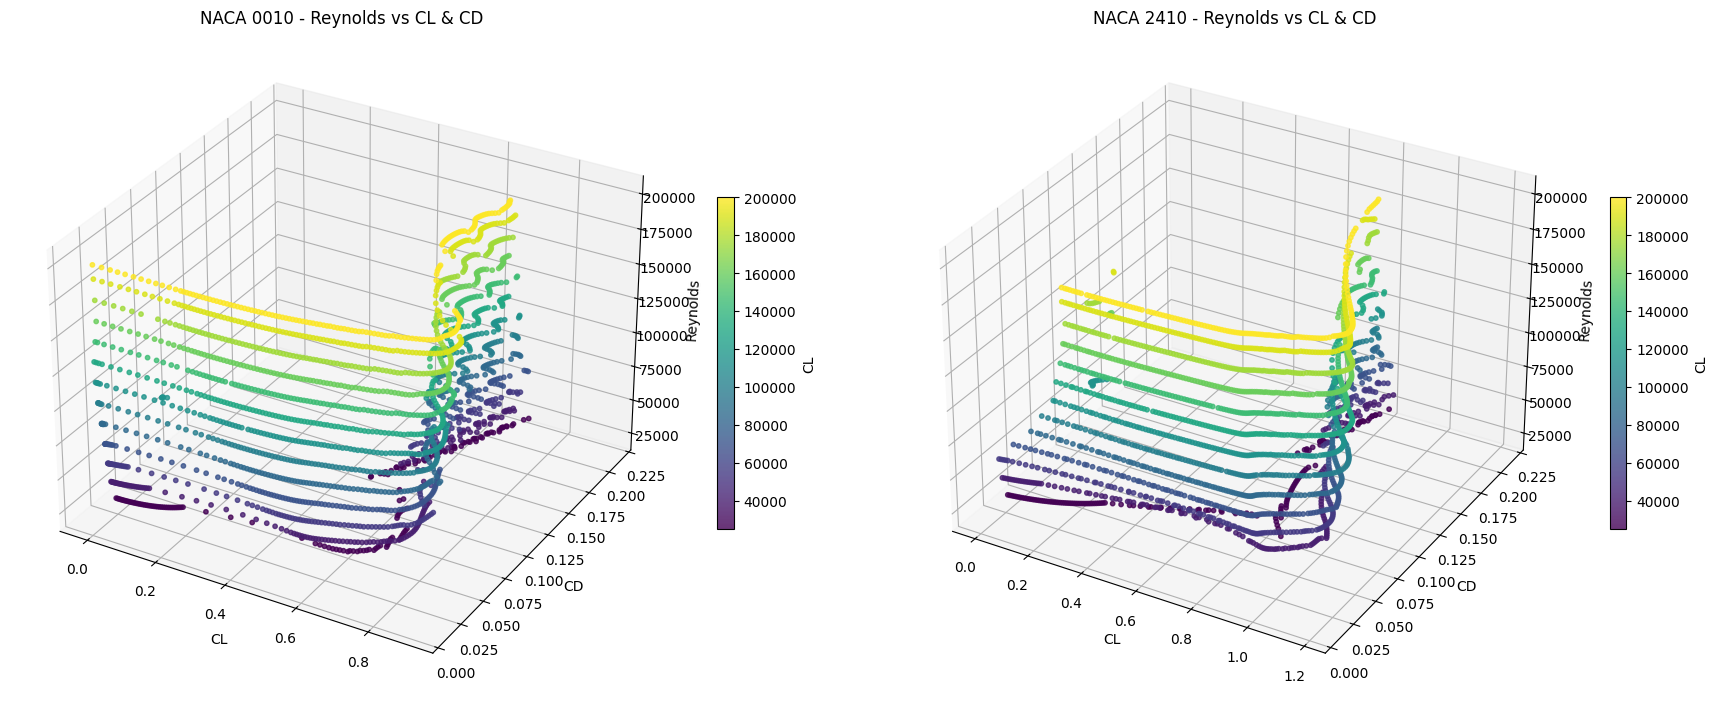

In [4]:
fig = plt.figure(figsize=(18, 7))

for i, naca in enumerate(["NACA 0010", "NACA 2410"]):
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    df_unique_naca = df[df.airfoil == naca]

    scatter = ax.scatter(
        df_unique_naca['CL'],
        df_unique_naca['CD'],
        df_unique_naca['Reynolds'],
        c=df_unique_naca['Reynolds'],
        cmap='viridis',
        s=10,
        alpha=0.8
    )

    ax.set_xlabel('CL')
    ax.set_ylabel('CD')
    ax.set_zlabel('Reynolds')
    ax.set_title(f'{naca} - Reynolds vs CL & CD')

    fig.colorbar(scatter, ax=ax, label='CL', shrink=0.5)

plt.tight_layout()
plt.show()

## Observations
As we can see in the plots, the impact of Reynolds and the NACA shape on the Cl and Cd coefficients is not linear. Since we cannot easily make a valid hypothesis on the function's form between Reynolds, alpha, Cd and Cl, we decided to use a Neural Network, wich allows us to approximate the function without knowing its shape.

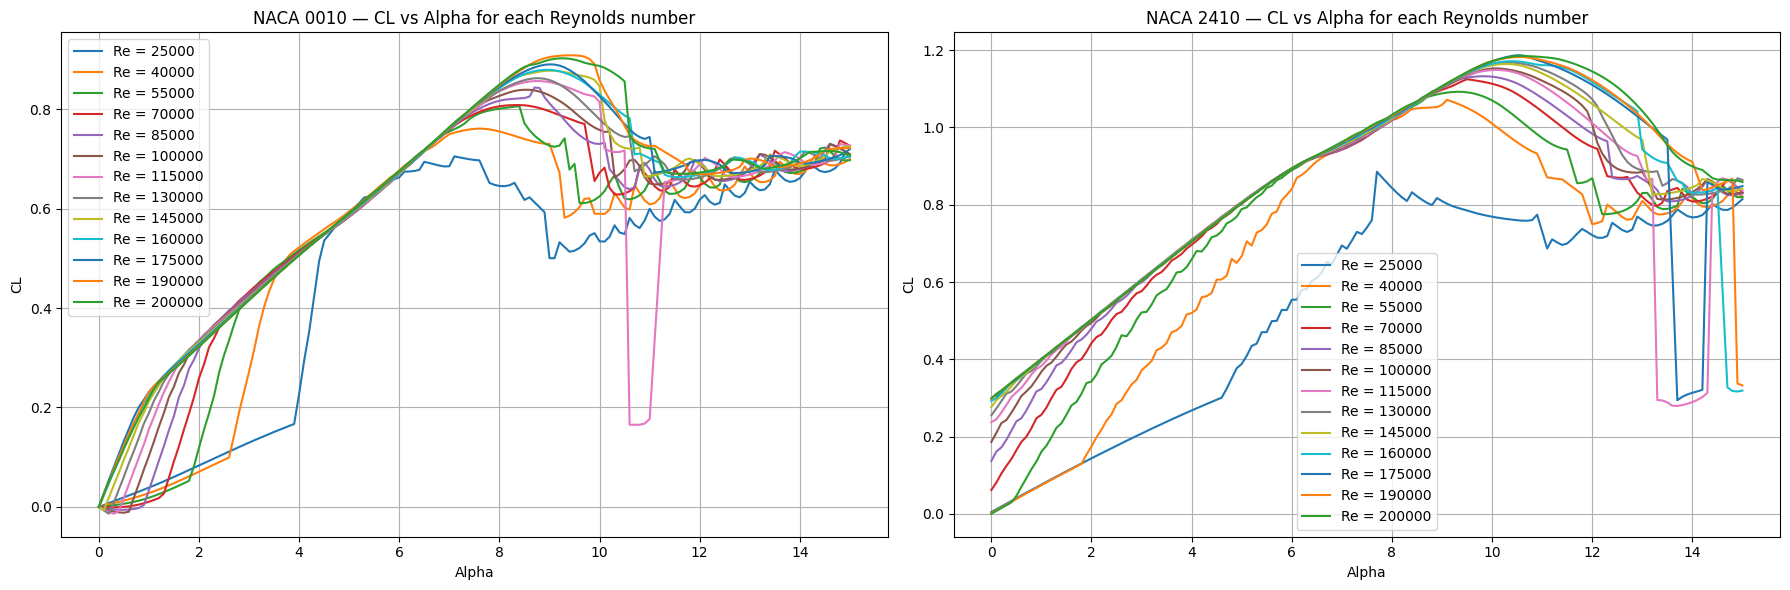

In [5]:
def plot_2d(threshold_fn):
  fig, axes = plt.subplots(1, 2, figsize=(18, 6))

  for ax, naca in zip(axes, ["NACA 0010", "NACA 2410"]):
      df_unique_naca = df[df.airfoil == naca]

      for re, group in df_unique_naca.groupby('Reynolds'):
          group_sorted = group.sort_values('alpha')
          ax.plot(group_sorted['alpha'], group_sorted['CL'], label=f'Re = {re:.0f}')


      alpha_full = df_unique_naca['alpha'].sort_values()
      if (threshold_fn):
        ax.plot(alpha_full, threshold_fn(alpha_full),
                label='Threshold', color='black', linestyle='--', linewidth=2)
      ax.set_xlabel('Alpha')
      ax.set_ylabel('CL')
      ax.set_title(f'{naca} — CL vs Alpha for each Reynolds number')
      ax.legend()
      ax.grid(True)

  plt.tight_layout()
  plt.show()

plot_2d(None)

Bricolage: Define a treshold on CL under which we consider the data point as an outlier.

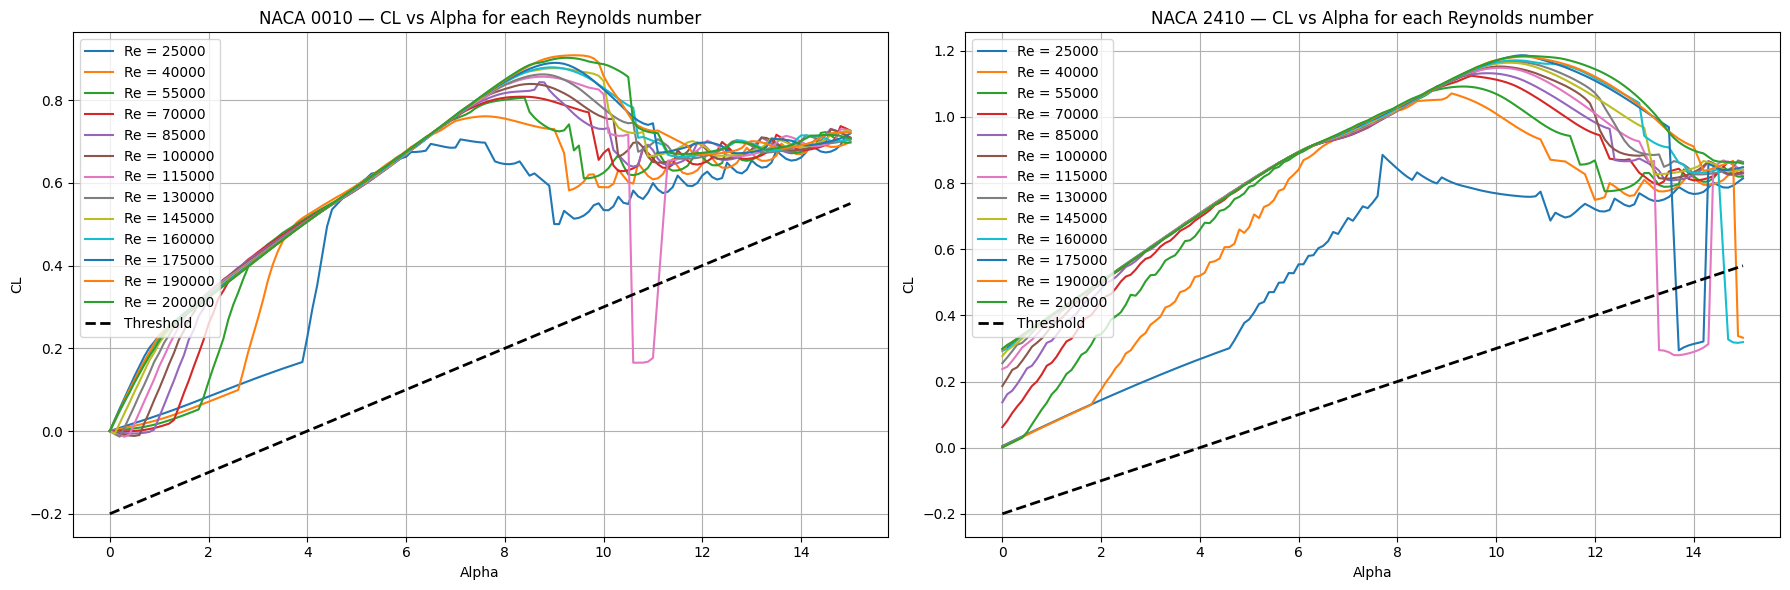

In [6]:
def threshold(x):
  return x*0.2/4 - 0.2

plot_2d(threshold)

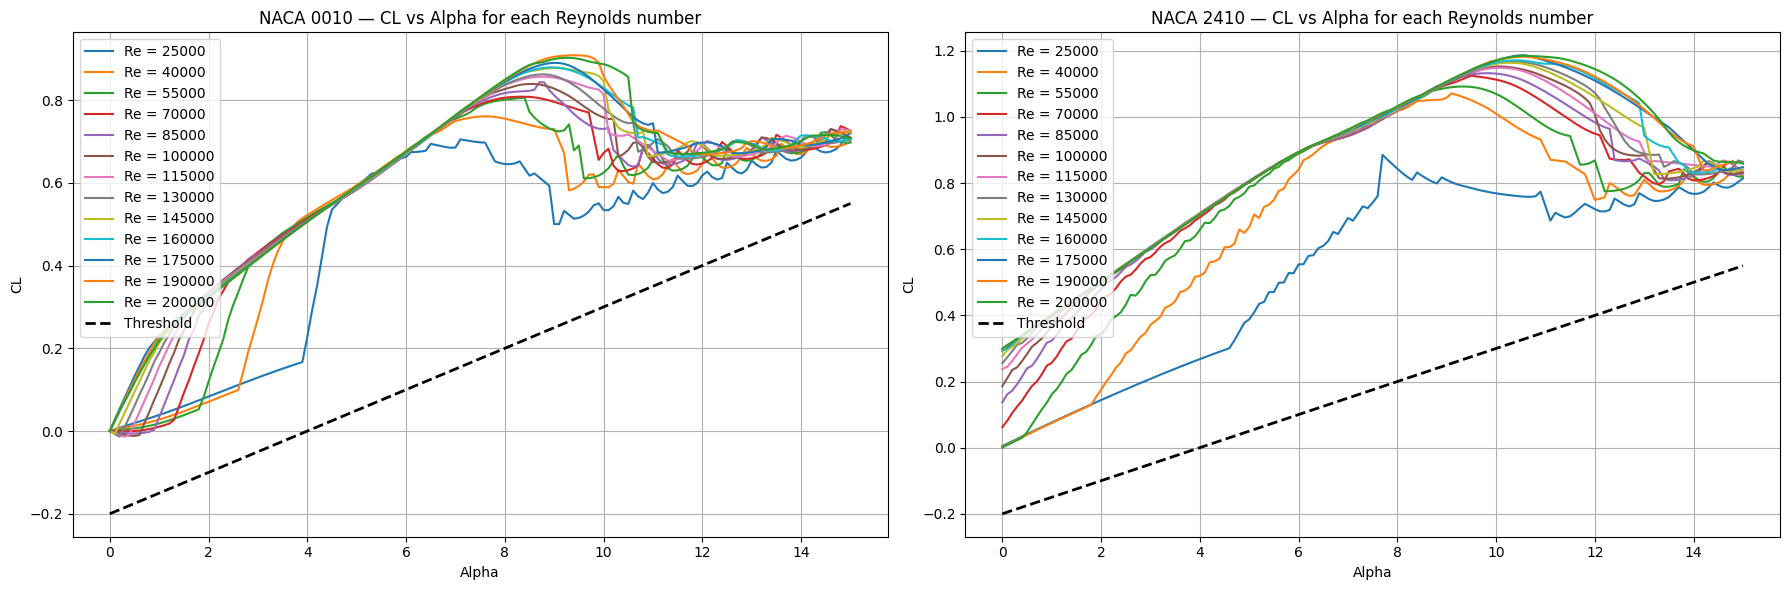

In [7]:
# Remove the outlier points
df = df[df['CL'] > threshold(df['alpha'])]

plot_2d(threshold)

# Feature Extraction
The `airfoil` feature encodes airfoil geometry as a NACA identifier (in our case `NACA 0010` and `NACA 2410`).
To make this information accessible to the model, we decompose it into explicit numerical features representing its physical parameters (camber, camber position, thickness).

In [8]:
def parse_naca4(naca_str):
    """
    Parse a NACA 4-digit airfoil code and return its geometric parameters.

    Parameters:
        naca_str (str): e.g. "NACA 0010", "NACA 2410", "0010", "2410"

    Reads:
        - max_camber     : as % of chord (e.g. 2 means 2%)
        - camber_position: position of max camber in tenths of chord
        - thickness      : as % of chord
    """
    code = naca_str.upper().replace("NACA", "").strip()

    if len(code) != 4 or not code.isdigit():
        raise ValueError(f"Expected a 4-digit NACA code, got: '{naca_str}'")

    max_camber      = int(code[0]) / 100   #devide by 100 to not have a percentage
    camber_position = int(code[1]) / 10    # position is a tenth of the chord
    thickness       = int(code[2:]) / 100

    return pd.Series([max_camber, camber_position, thickness])
df[['max_camber', 'camber_position', 'thickness']] = df['airfoil'].apply(parse_naca4)
df.head(10)

# test_cases = ["NACA 0010", "NACA 2410", "NACA 0006", "NACA 2420"]
# for naca in test_cases:
#     result = parse_naca4(naca)
#     print(f"{naca}  →  max_camber={result[0]}, camber_pos={result[1]}0 chord, thickness={result[2]}")


,airfoil,Reynolds,alpha,CL,CD,max_camber,camber_position,thickness
0,NACA 0010,25000,0.0,-0.0000,0.02381,0.0,0.0,0.1
1,NACA 0010,25000,0.1,0.0039,0.02382,0.0,0.0,0.1
2,NACA 0010,25000,0.2,0.0077,0.02383,0.0,0.0,0.1
3,NACA 0010,25000,0.3,0.0116,0.02386,0.0,0.0,0.1
4,NACA 0010,25000,0.4,0.0154,0.02389,0.0,0.0,0.1
5,NACA 0010,25000,0.5,0.0192,0.02393,0.0,0.0,0.1
6,NACA 0010,25000,0.6,0.0230,0.02399,0.0,0.0,0.1
7,NACA 0010,25000,0.7,0.0268,0.02406,0.0,0.0,0.1
8,NACA 0010,25000,0.8,0.0308,0.02413,0.0,0.0,0.1
9,NACA 0010,25000,0.9,0.0348,0.02422,0.0,0.0,0.1


#Creating the neural network

In [9]:
class MyNeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_hidden_layers):
        super().__init__()
        layers = []

        # Input → first hidden
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())

        # Remaining hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())

        # Last hidden → output (no activation on output)
        layers.append(nn.Linear(hidden_size, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [10]:
# Input
X = df[['max_camber', 'camber_position', 'thickness', 'Reynolds', 'alpha']].values

# Output
Y = df[['CL', 'CD']].values

# Splitting between training and testing sets

Train: 2681, Test: 1150


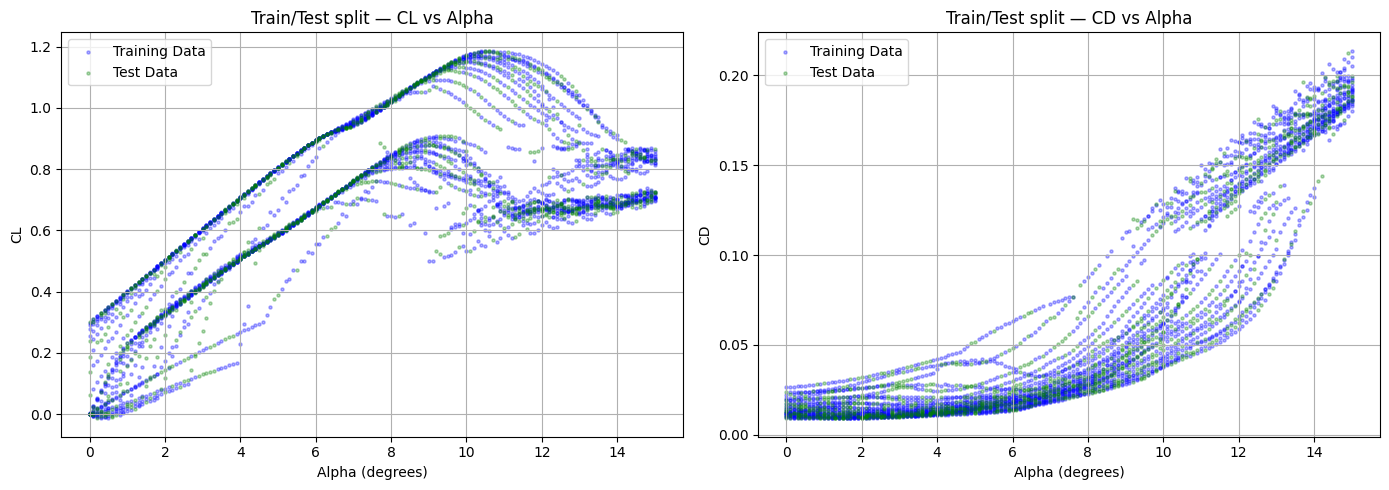

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.float32)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CL
axes[0].scatter(X_train[:, 4], Y_train[:, 0], c='b', alpha=0.3, s=5, label='Training Data')
axes[0].scatter(X_test[:, 4],  Y_test[:, 0],  c='g', alpha=0.3, s=5, label='Test Data')
axes[0].set_xlabel('Alpha (degrees)')
axes[0].set_ylabel('CL')
axes[0].set_title('Train/Test split — CL vs Alpha')
axes[0].legend()
axes[0].grid(True)

# CD
axes[1].scatter(X_train[:, 4], Y_train[:, 1], c='b', alpha=0.3, s=5, label='Training Data')
axes[1].scatter(X_test[:, 4],  Y_test[:, 1],  c='g', alpha=0.3, s=5, label='Test Data')
axes[1].set_xlabel('Alpha (degrees)')
axes[1].set_ylabel('CD')
axes[1].set_title('Train/Test split — CD vs Alpha')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Scaling data

In [12]:
# Scale based on TRAINING data only
def scale(X, Xmin, Xmax):
    denom = Xmax - Xmin
    denom = torch.where(denom == 0, torch.ones_like(denom), denom)
    return 2 * (X - Xmin) / denom - 1


X_min, X_max = X_train_t.min(dim=0).values, X_train_t.max(dim=0).values
Y_min, Y_max = Y_train_t.min(dim=0).values, Y_train_t.max(dim=0).values

X_train_s = scale(X_train_t, X_min, X_max)
X_test_s  = scale(X_test_t,  X_min, X_max)
Y_train_s = scale(Y_train_t, Y_min, Y_max)
Y_test_s  = scale(Y_test_t,  Y_min, Y_max)

# Different def scale than in the excersices since the collumn of thickness caused an issue (giving 0 everywhere)
#Check up of the code to see if we have any "NAN" output
#print("X_min:", X_min)
# print("X_max:", X_max)
# print("Difference (should not be 0):", X_max - X_min)
print("\nAny nan in X_train_s?", torch.isnan(X_train_s).any().item())
print("Any nan in Y_train_s?", torch.isnan(Y_train_s).any().item())

print(X_train_s)
print(X_test_s)


Any nan in X_train_s? False
Any nan in Y_train_s? False
tensor([[ 1.0000,  1.0000, -1.0000, -0.8286, -0.7067],
        [ 1.0000,  1.0000, -1.0000,  0.8857,  0.3200],
        [ 1.0000,  1.0000, -1.0000, -0.8286,  0.4800],
        ...,
        [-1.0000, -1.0000, -1.0000, -0.1429,  0.5200],
        [ 1.0000,  1.0000, -1.0000,  0.7143,  0.5467],
        [ 1.0000,  1.0000, -1.0000,  0.3714,  0.0000]])
tensor([[ 1.0000,  1.0000, -1.0000, -0.6571,  0.4267],
        [-1.0000, -1.0000, -1.0000,  0.2000,  0.9867],
        [ 1.0000,  1.0000, -1.0000, -0.3143,  0.9867],
        ...,
        [-1.0000, -1.0000, -1.0000, -0.8286,  0.8400],
        [-1.0000, -1.0000, -1.0000,  0.3714, -0.5467],
        [ 1.0000,  1.0000, -1.0000, -0.4857, -0.0800]])


# Construction and training of the model

In [13]:
torch.manual_seed(42)

lambda_reg = 0.00008
input_size = X_train_s.shape[1] # Explicitely link the number of input to the number of features
hidden_size = 32  #number of neurons per hidden layer
output_size = 2
num_hidden_layers = 3

model = MyNeuralNetwork(input_size, hidden_size, output_size, num_hidden_layers)
print(model)
criterion = nn.MSELoss()
optimiser = optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=200)

MyNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


Epoch [500/10000], Train: 0.0174, Val: 0.0173
Epoch [1000/10000], Train: 0.0133, Val: 0.0132
Epoch [1500/10000], Train: 0.0107, Val: 0.0107
Epoch [2000/10000], Train: 0.0088, Val: 0.0089
Epoch [2500/10000], Train: 0.0073, Val: 0.0073
Epoch [3000/10000], Train: 0.0061, Val: 0.0061
Epoch [3500/10000], Train: 0.0053, Val: 0.0053
Epoch [4000/10000], Train: 0.0048, Val: 0.0049
Epoch [4500/10000], Train: 0.0045, Val: 0.0046
Epoch [5000/10000], Train: 0.0044, Val: 0.0045
Epoch [5500/10000], Train: 0.0043, Val: 0.0043
Epoch [6000/10000], Train: 0.0042, Val: 0.0042
Epoch [6500/10000], Train: 0.0041, Val: 0.0042
Epoch [7000/10000], Train: 0.0040, Val: 0.0041
Epoch [7500/10000], Train: 0.0040, Val: 0.0041
Epoch [8000/10000], Train: 0.0039, Val: 0.0040
Epoch [8500/10000], Train: 0.0039, Val: 0.0040
Epoch [9000/10000], Train: 0.0039, Val: 0.0040
Epoch [9500/10000], Train: 0.0039, Val: 0.0040
Epoch [10000/10000], Train: 0.0039, Val: 0.0040

Best validation loss: 0.0040


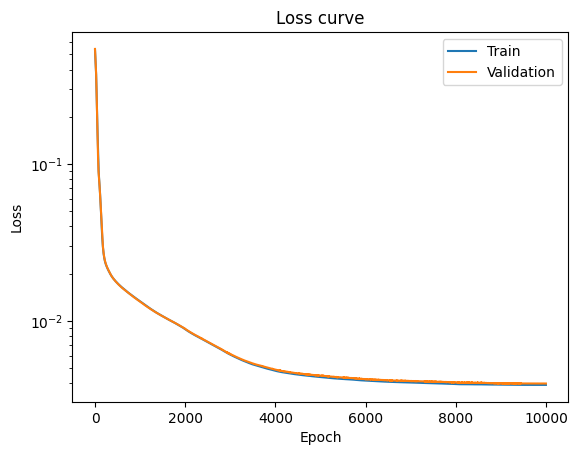

In [14]:
# neural network + L1 regularisation

train_loss_list = []
test_loss_list  = []
num_epochs      = 10000

# Early stopping settings
best_val_loss      = float('inf')
patience           = 500
epochs_no_improve  = 0
best_model_weights = None

for epoch in range(num_epochs):

    output = model(X_train_s)
    loss = criterion(output, Y_train_s)

    l1 = sum(torch.norm(p, 1) for p in model.parameters())
    loss_total = loss + lambda_reg * l1

    with torch.no_grad():
        output_test = model(X_test_s)
        loss_test = criterion(output_test, Y_test_s) + lambda_reg * l1

    optimiser.zero_grad()
    loss_total.backward()
    optimiser.step()

    train_loss_list.append(loss_total.item())
    test_loss_list.append(loss_test.item())

    # Early stopping check
    if loss_test.item() < best_val_loss:
        best_val_loss  = loss_test.item()
        epochs_no_improve = 0
        best_model_weights = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        model.load_state_dict(best_model_weights)
        break

    scheduler.step(loss_test.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train: {loss_total.item():.4f}, Val: {loss_test.item():.4f}")

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)

print(f"\nBest validation loss: {best_val_loss:.4f}")

# Plot loss curve
plt.plot(train_loss_list, label='Train')
plt.plot(test_loss_list,  label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.title('Loss curve')
plt.show()

# Visualization of the model results

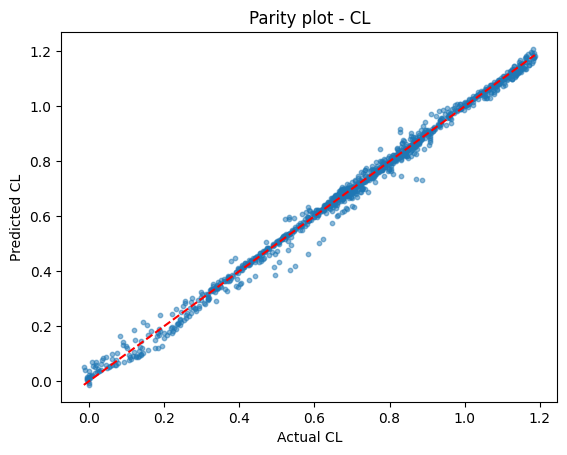

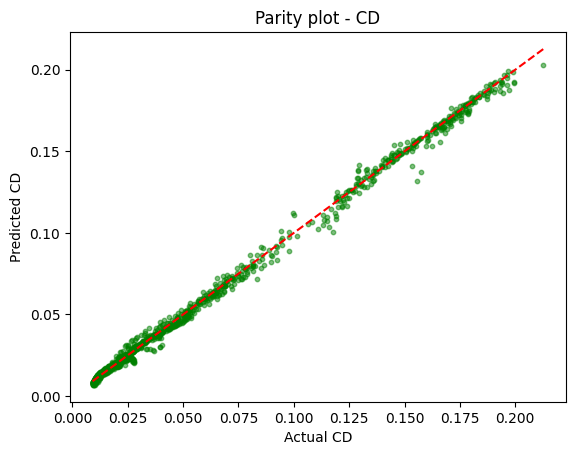

In [15]:
def unscale(X_scaled, Xmin, Xmax):
    denom = Xmax - Xmin
    denom = torch.where(denom == 0, torch.ones_like(denom), denom)
    return (X_scaled + 1) / 2 * denom + Xmin

with torch.no_grad():
    Y_pred_s = model(X_test_s)
    Y_pred = unscale(Y_pred_s, Y_min, Y_max)
    Y_actual = unscale(Y_test_s, Y_min, Y_max)

# Parity plot for CL
plt.scatter(Y_actual[:, 0], Y_pred[:, 0], alpha=0.5, s=10)
plt.plot([Y_actual[:, 0].min(), Y_actual[:, 0].max()],
         [Y_actual[:, 0].min(), Y_actual[:, 0].max()], 'r--')
plt.xlabel('Actual CL'); plt.ylabel('Predicted CL')
plt.title('Parity plot - CL'); plt.show()

# Parity plot for CD
plt.scatter(Y_actual[:, 1], Y_pred[:, 1], alpha=0.5, s=10, color='green')
plt.plot([Y_actual[:, 1].min(), Y_actual[:, 1].max()],
         [Y_actual[:, 1].min(), Y_actual[:, 1].max()], 'r--')
plt.xlabel('Actual CD'); plt.ylabel('Predicted CD')
plt.title('Parity plot - CD'); plt.show()

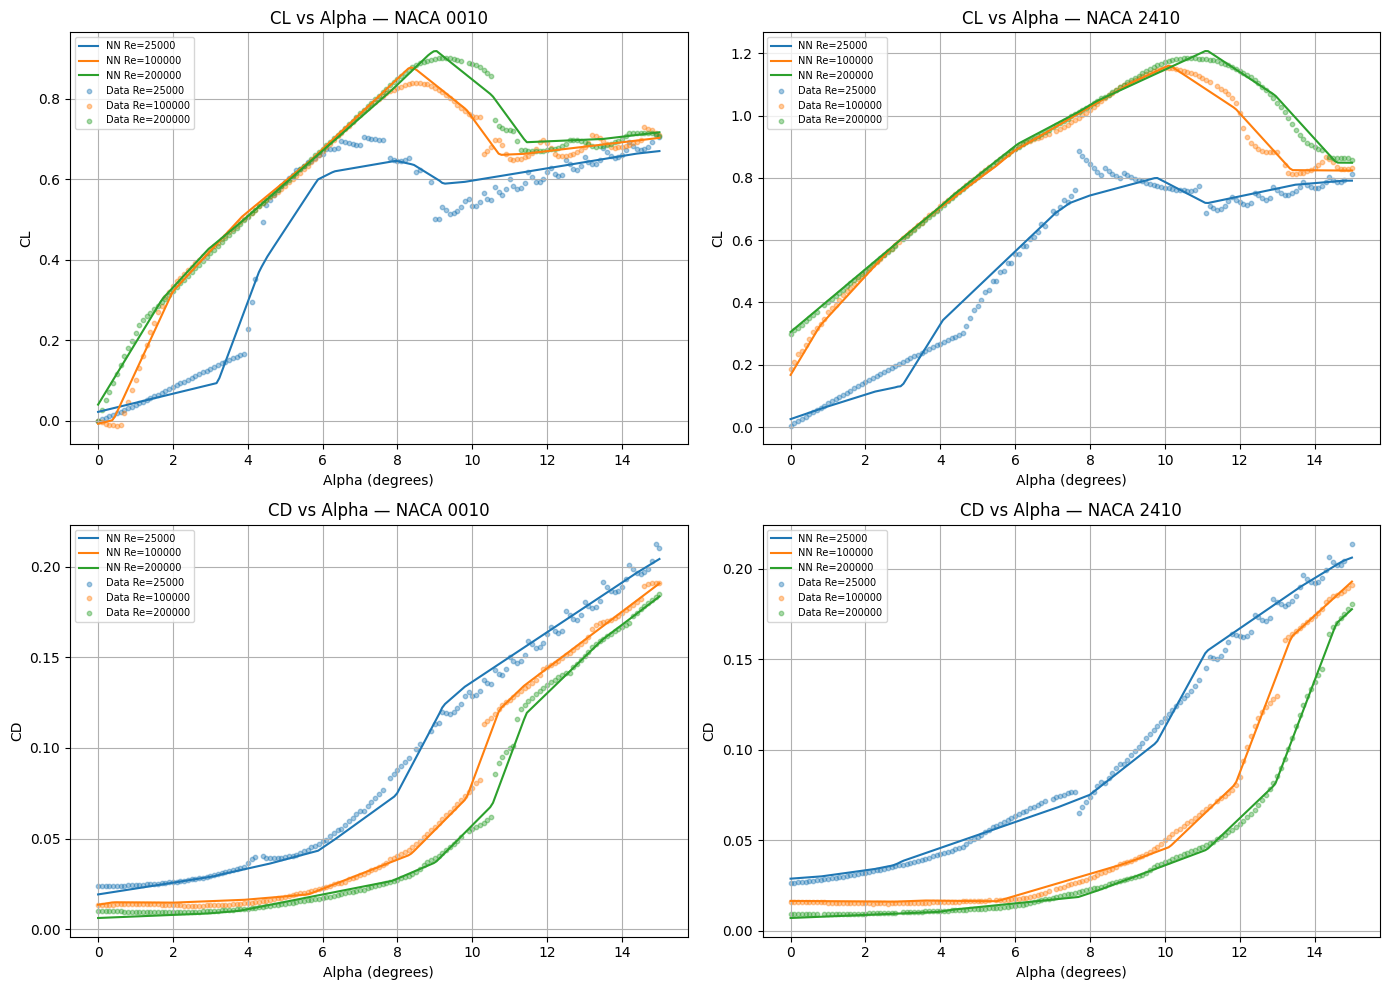

In [16]:
# Step 8b - Visualisation of NN predictions vs actual data

# Pick specific conditions to visualise
re_values = [25000, 100000, 200000]  # pick a few Reynolds numbers to compare
airfoils  = ['NACA 0010', 'NACA 2410']
alpha_range = torch.linspace(0, 15, 200)  # smooth alpha sweep for plotting

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, airfoil in enumerate(airfoils):
    # Parse geometry for this airfoil
    geom = parse_naca4(airfoil)  # returns [max_camber, camber_pos, thickness]

    for re in re_values:
        # Build input tensor for the alpha sweep
        n = len(alpha_range)
        X_plot = torch.zeros(n, 5)
        X_plot[:, 0] = geom[0]           # max_camber
        X_plot[:, 1] = geom[1]           # camber_position
        X_plot[:, 2] = geom[2]           # thickness
        X_plot[:, 3] = re                # Reynolds
        X_plot[:, 4] = alpha_range       # alpha sweep

        # Scale and predict
        X_plot_s = scale(X_plot, X_min, X_max)
        with torch.no_grad():
            Y_plot_s = model(X_plot_s)
            Y_plot   = unscale(Y_plot_s, Y_min, Y_max)

        # Plot predicted curves
        axes[0, col].plot(alpha_range, Y_plot[:, 0], label=f'NN Re={re:.0f}')
        axes[1, col].plot(alpha_range, Y_plot[:, 1], label=f'NN Re={re:.0f}')

    # Overlay actual data points
    df_foil = df[df['airfoil'] == airfoil]
    for re in re_values:
        df_re = df_foil[df_foil['Reynolds'] == re].sort_values('alpha')
        axes[0, col].scatter(df_re['alpha'], df_re['CL'], s=10, alpha=0.4, label=f'Data Re={re:.0f}')
        axes[1, col].scatter(df_re['alpha'], df_re['CD'], s=10, alpha=0.4, label=f'Data Re={re:.0f}')

    # Labels
    axes[0, col].set_title(f'CL vs Alpha — {airfoil}')
    axes[0, col].set_xlabel('Alpha (degrees)')
    axes[0, col].set_ylabel('CL')
    axes[0, col].legend(fontsize=7)
    axes[0, col].grid(True)

    axes[1, col].set_title(f'CD vs Alpha — {airfoil}')
    axes[1, col].set_xlabel('Alpha (degrees)')
    axes[1, col].set_ylabel('CD')
    axes[1, col].legend(fontsize=7)
    axes[1, col].grid(True)

plt.tight_layout()
plt.show()